In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import math
import random as rd
import cobra
from cobra.sampling.achr import ACHRSampler
from cobra.sampling.core import step


In [2]:
"""
Boltzmann-biased ACHR sampler for COBRApy
=========================================

Implements a numerically stable Metropolis–Hastings ACHR sampler that biases
flux distributions toward higher values of selected reactions using per-reaction
β parameters.  Automatically scales β values via a short unbiased pilot run and
supports optional annealing (gradually increasing β).

Example
-------
from cobra.sampling.biased_sampler import BiasedSampler
from cobra import test

model = test.create_test_model("textbook")
sampler = BiasedSampler(
    model,
    reactions=["EX_glc__D_e", "ATPM"],
    betas=[2.0, 8.0],       # relative weights (scaled automatically)
    auto_scale=True,        # normalize by pilot std dev
    anneal_steps=2000,      # gradually ramp β to full strength
)
samples = sampler.sample(500)
print(samples[["EX_glc__D_e", "ATPM"]].describe())
"""


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import gaussian_kde
import math
import random as rd
import cobra
from cobra.sampling.achr import ACHRSampler
from cobra.sampling.core import step


class BiasedSampler(ACHRSampler):
    """Boltzmann-biased ACHR sampler with multiple β, auto-scaling and annealing."""

    def __init__(
        self,
        model,
        reactions,
        betas=1.0,
        thinning=100,
        nproj=None,
        seed=None,
        auto_scale=True,
        pilot_samples=300,
        anneal_steps=0,
        verbose=True,
        **kwargs,
    ):
        """
        Parameters
        ----------
        model : cobra.Model
            COBRA model to sample.
        reactions : list of str
            Target reaction IDs.
        betas : float or list of float
            Bias strengths (one per reaction or scalar).
        auto_scale : bool, optional
            If True, scale betas by 1/std(target flux) estimated from a short
            unbiased pilot run (default True).
        pilot_samples : int, optional
            Number of pilot samples for scaling (default 300).
        anneal_steps : int, optional
            Number of sampling iterations over which to ramp β from 0 to full
            value (default 0 means no annealing).
        verbose : bool, optional
            Print diagnostic info (default True).
        """
        super().__init__(model, thinning=thinning, nproj=nproj, seed=seed, **kwargs)
        self.target_rxns = [model.reactions.get_by_id(r) for r in reactions]

        if np.isscalar(betas):
            betas = [float(betas)] * len(reactions)
        elif len(betas) != len(reactions):
            raise ValueError("`betas` must be scalar or same length as `reactions`")

        self.base_betas = np.array(betas, dtype=float)
        self.betas = self.base_betas.copy()
        self.anneal_steps = int(anneal_steps)
        self.verbose = verbose

        # Map reactions to indices
        rxn_ids = [r.id for r in model.reactions]
        self.target_idx = np.array([rxn_ids.index(r.id) for r in self.target_rxns])

        # Optionally scale betas by inverse std from pilot run
        if auto_scale:
            if verbose:
                print(f"[BiasedSampler] Running pilot sampling ({pilot_samples} samples)...")
            pilot = self._pilot_sample(pilot_samples)
            stds = pilot.std(axis=0)
            stds[stds == 0] = 1.0
            self.betas = self.base_betas / stds
            if verbose:
                print("[BiasedSampler] Pilot stds:",
                      {r.id: round(s, 3) for r, s in zip(self.target_rxns, stds)})
                print("[BiasedSampler] Scaled betas:",
                      {r.id: round(b, 3) for r, b in zip(self.target_rxns, self.betas)})

        self.accepted = 0
        self.trials = 0

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _pilot_sample(self, n=200):
        """Run a short unbiased ACHR sampling to estimate stds."""
        from cobra.sampling.achr import ACHRSampler
        tmp = ACHRSampler(self.model, thinning=self.thinning, seed=self._seed + 1)
        pilot_df = tmp.sample(n)
        return pilot_df[[r.id for r in self.target_rxns]]

    def _log_weight(self, fluxes):
        """Compute log weight (sum beta_i * v_i) for numerical stability."""
        return float(np.dot(self.betas, fluxes[self.target_idx]))

    def _current_beta_scale(self):
        """If annealing, compute current scaling factor in [0,1]."""
        if self.anneal_steps <= 0 or self.n_samples >= self.anneal_steps:
            return 1.0
        return self.n_samples / max(1, self.anneal_steps)

    # ------------------------------------------------------------------
    # Single MH iteration
    # ------------------------------------------------------------------

    def __single_iteration(self):
        pi = np.random.randint(self.n_warmup)
        delta = self.warmup[pi, :] - self.center
        candidate = step(self, self.prev, delta)

        flux_prev = self.prev[self.fwd_idx] - self.prev[self.rev_idx]
        flux_cand = candidate[self.fwd_idx] - candidate[self.rev_idx]

        scale = self._current_beta_scale()
        log_old = scale * self._log_weight(flux_prev)
        log_new = scale * self._log_weight(flux_cand)
        log_acc = log_new - log_old

        self.trials += 1
        if log_acc >= 0 or np.log(np.random.rand()) < log_acc:
            self.prev = candidate
            self.accepted += 1

        self.center = (self.n_samples * self.center + self.prev) / (self.n_samples + 1)
        self.n_samples += 1

    # ------------------------------------------------------------------
    # Public sampling interface
    # ------------------------------------------------------------------

    def sample(self, n: int, fluxes: bool = True) -> pd.DataFrame:
        """Generate biased flux samples with optional annealing."""
        samples = np.zeros((n, self.warmup.shape[1]))

        for i in range(1, self.thinning * n + 1):
            self.__single_iteration()
            if i % self.thinning == 0:
                samples[i // self.thinning - 1, :] = self.prev

        acc_rate = self.accepted / max(1, self.trials)
        if self.verbose:
            print(f"[BiasedSampler] Acceptance rate: {acc_rate:.3f}")
            print(f"[BiasedSampler] Final β effective scale: {self._current_beta_scale():.2f}")

        if fluxes:
            names = [r.id for r in self.model.reactions]
            return pd.DataFrame(
                samples[:, self.fwd_idx] - samples[:, self.rev_idx],
                columns=names,
            ), self.betas
        else:
            names = [v.name for v in self.model.variables]
            return pd.DataFrame(samples, columns=names) , self._current_beta_scale()
        


In [19]:

model = cobra.io.load_model("textbook")
model.reactions.EX_ac_e.lower_bound = -8
sampler = BiasedSampler(model, reactions=["Biomass_Ecoli_core", "EX_ac_e"], betas=[12,11.1],
                        anneal_steps=2000, verbose=False,  pilot_samples = 1000, auto_scale=True)
samples, betas = sampler.sample(2000)



In [7]:

model = cobra.io.load_model("textbook")
model.reactions.EX_ac_e.lower_bound = -8
sampler = BiasedSampler(model, reactions=["Biomass_Ecoli_core", "EX_ac_e"], betas=[100,0],
                        anneal_steps=2000, verbose=False,  pilot_samples = 1000, auto_scale=False)
samples, betas = sampler.sample(2000)


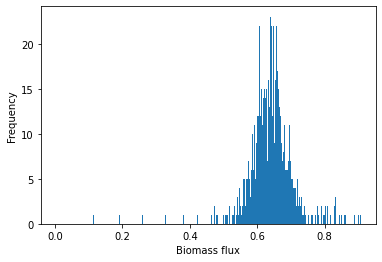

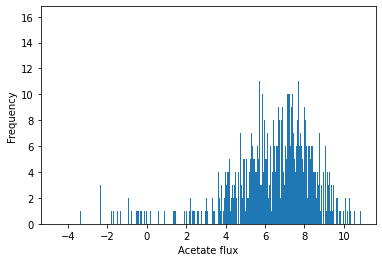

In [18]:

plt.hist(samples["Biomass_Ecoli_core"], bins=1000)
plt.xlabel("Biomass flux")
plt.ylabel("Frequency")
plt.show()

plt.hist(samples["EX_ac_e"], bins=1000)
plt.xlabel("Acetate flux")
plt.ylabel("Frequency")
plt.show()